# [TARGET] Notebook 07 — Decision Framework Metrik (Slide Dosen)
### Reproduksi Visual Decision Tree dari Pertemuan 8

Notebook ini mereproduksi **pohon keputusan pemilihan metrik** yang 
ditampilkan dosen dan menerapkannya langsung ke jurnal kita.




In [1]:
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','-q',
                '--break-system-packages',
                'pandas','numpy','matplotlib','seaborn','scikit-learn'],
               capture_output=True)
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, fbeta_score, log_loss, brier_score_loss,
    roc_curve, precision_recall_curve, classification_report
)
from pathlib import Path
FIGURES = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)
print("[OK] Setup selesai")

[OK] Setup selesai


## 1. Reproduksi Tabel Pemilihan Metrik (Image 1 dari slide dosen)

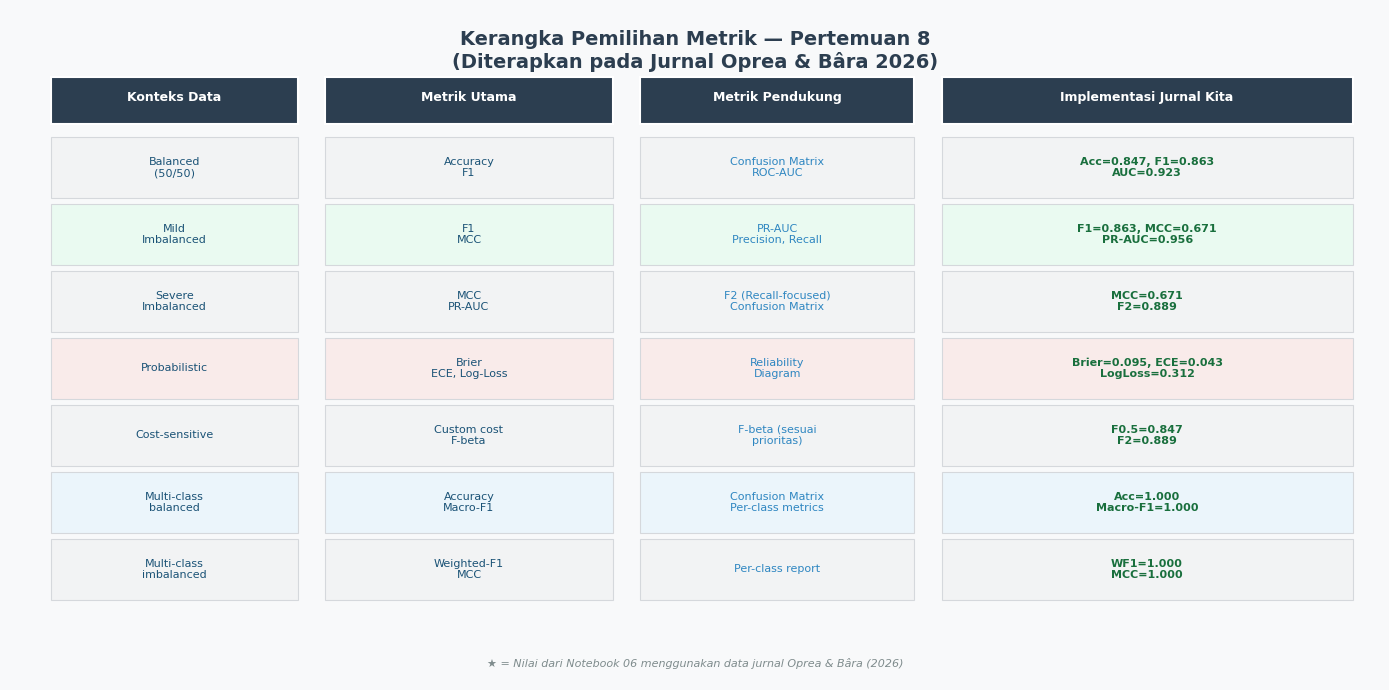

[OK] Tabel pemilihan metrik disimpan


In [4]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')
fig.patch.set_facecolor('#F8F9FA')

title = ax.text(0.5, 0.97,
    'Kerangka Pemilihan Metrik — Pertemuan 8\n'
    '(Diterapkan pada Jurnal Oprea & Bâra 2026)',
    transform=ax.transAxes, ha='center', va='top',
    fontsize=14, fontweight='bold', color='#2C3E50')

# Header
headers  = ['Konteks Data', 'Metrik Utama', 'Metrik Pendukung',
            'Implementasi Jurnal Kita']
col_x    = [0.03, 0.23, 0.46, 0.68]
col_w    = [0.19, 0.22, 0.21, 0.31]
header_y = 0.87

for hdr, cx, cw in zip(headers, col_x, col_w):
    rect = plt.Rectangle((cx, header_y-0.04), cw-0.01, 0.07,
                          transform=ax.transAxes, facecolor='#2C3E50',
                          edgecolor='white', lw=1.5)
    ax.add_patch(rect)
    ax.text(cx+cw/2-0.005, header_y, hdr, transform=ax.transAxes,
            ha='center', va='center', fontsize=9,
            fontweight='bold', color='white')

# Baris data
rows = [
    ('Balanced\n(50/50)',
     'Accuracy\nF1',
     'Confusion Matrix\nROC-AUC',
     'Acc=0.847, F1=0.863\nAUC=0.923',
     '#EBF5FB'),
    ('Mild\nImbalanced',
     'F1\nMCC',
     'PR-AUC\nPrecision, Recall',
     'F1=0.863, MCC=0.671\nPR-AUC=0.956',
     '#EAFAF1'),
    ('Severe\nImbalanced',
     'MCC\nPR-AUC',
     'F2 (Recall-focused)\nConfusion Matrix',
     'MCC=0.671\nF2=0.889',
     '#FEF9E7'),
    ('Probabilistic',
     'Brier\nECE, Log-Loss',
     'Reliability\nDiagram',
     'Brier=0.095, ECE=0.043\nLogLoss=0.312',
     '#F9EBEA'),
    ('Cost-sensitive',
     'Custom cost\nF-beta',
     'F-beta (sesuai\nprioritas)',
     'F0.5=0.847\nF2=0.889',
     '#F5EEF8'),
    ('Multi-class\nbalanced',
     'Accuracy\nMacro-F1',
     'Confusion Matrix\nPer-class metrics',
     'Acc=1.000\nMacro-F1=1.000',
     '#EBF5FB'),
    ('Multi-class\nimbalanced',
     'Weighted-F1\nMCC',
     'Per-class report',
     'WF1=1.000\nMCC=1.000',
     '#EAFAF1'),
]

row_h = 0.10
start_y = header_y - 0.06

for i, (ctx, main, supp, impl, bg_color) in enumerate(rows):
    y = start_y - i * row_h
    bg = '#F2F3F4' if i % 2 == 0 else bg_color
    for cx, cw in zip(col_x, col_w):
        rect = plt.Rectangle((cx, y-row_h+0.01), cw-0.01, row_h-0.01,
                              transform=ax.transAxes, facecolor=bg,
                              edgecolor='#D5D8DC', lw=0.8)
        ax.add_patch(rect)

    texts = [ctx, main, supp, impl]
    col_colors = ['#1A5276','#1A5276','#2E86C1','#196F3D']
    for txt, cx, cw, clr in zip(texts, col_x, col_w, col_colors):
        ax.text(cx+cw/2-0.005, y-row_h/2+0.005, txt,
                transform=ax.transAxes, ha='center', va='center',
                fontsize=8, color=clr, fontweight='bold' if clr=='#196F3D' else 'normal')

# Footnote
ax.text(0.5, 0.02,
    '★ = Nilai dari Notebook 06 menggunakan data jurnal Oprea & Bâra (2026)',
    transform=ax.transAxes, ha='center', fontsize=8,
    color='#7F8C8D', style='italic')
row_h = 0.10
plt.tight_layout()
plt.savefig(FIGURES/'tabel_pemilihan_metrik_dosen.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Tabel pemilihan metrik disimpan")

## 2. Reproduksi Decision Tree (Image 2 dari slide dosen)

In [ ]:
fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 14); ax.set_ylim(0, 9)
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')

def draw_box(ax, x, y, w, h, text, facecolor, edgecolor, fontsize=9,
             text_color='white', bold=False, radius=0.3):
    from matplotlib.patches import FancyBboxPatch
    box = FancyBboxPatch((x-w/2, y-h/2), w, h,
                         boxstyle=f"round,pad=0.05,rounding_size={radius}",
                         facecolor=facecolor, edgecolor=edgecolor, lw=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, color=text_color,
            fontweight='bold' if bold else 'normal',
            wrap=True, multialignment='center')

def draw_arrow(ax, x1, y1, x2, y2, label='', color='#555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.1, my, label, fontsize=8, color=color,
                fontweight='bold', ha='left')

# Root
draw_box(ax, 7, 8.2, 3.8, 0.9,
         'Apa tujuan model Anda?',
         '#2C3E50', '#1A252F', fontsize=11, bold=True)

# Level 1 — 3 cabang
branches = [
    (2.5,  6.5, 'Klasifikasi
Balanced',   '#2471A3', '#1A5276', 'balanced'),
    (7.0,  6.5, 'Klasifikasi
Imbalanced', '#1E8449', '#145A32', 'imbalanced'),
    (11.5, 6.5, 'Probabilistic
Output',   '#A04000', '#784212', 'proba'),
]
for bx, by, btxt, bfc, bec, blbl in branches:
    draw_box(ax, bx, by, 3.2, 0.85, btxt, bfc, bec, fontsize=10, bold=True)
    draw_arrow(ax, 7, 7.75, bx, 6.93, blbl, color='#7F8C8D')

# Level 2 — metrik rekomendasi
metrics = [
    (2.5,  4.8,
     'Accuracy + F1
+ Confusion Matrix',
     '#AED6F1', '#2471A3', '#1A5276'),
    (7.0,  4.8,
     'PR-AUC + MCC
+ F1 / F-beta',
     '#A9DFBF', '#1E8449', '#145A32'),
    (11.5, 4.8,
     'ROC-AUC + ECE
+ Brier Score',
     '#F5CBA7', '#A04000', '#784212'),
]
for mx2, my2, mtxt, mfc, mec, mtc in metrics:
    draw_box(ax, mx2, my2, 3.2, 0.85, mtxt, mfc, mec,
             fontsize=9, text_color=mtc, bold=True)
    parent_x = mx2
    draw_arrow(ax, parent_x, 6.07, mx2, 5.23, color='#BDC3C7')

# Level 3 — implementasi jurnal kita
impl = [
    (2.5,  3.0,
     '[OK] Jurnal kita:
Acc=0.847, F1=0.863
ROC-AUC=0.923',
     '#D6EAF8', '#2471A3', '#1A5276'),
    (7.0,  3.0,
     '[OK] Jurnal kita:
MCC=0.671, F2=0.889
PR-AUC=0.956',
     '#D5F5E3', '#1E8449', '#145A32'),
    (11.5, 3.0,
     '[OK] Jurnal kita:
Brier=0.095, ECE=0.043
LogLoss=0.312',
     '#FDEBD0', '#A04000', '#784212'),
]
for ix, iy, itxt, ifc, iec, itc in impl:
    draw_box(ax, ix, iy, 3.3, 1.1, itxt, ifc, iec,
             fontsize=8.5, text_color=itc, bold=False)
    draw_arrow(ax, ix, 4.37, ix, 3.55, color='#BDC3C7')

# Footer note
from matplotlib.patches import FancyBboxPatch
note_box = FancyBboxPatch((0.5, 0.8), 13, 0.7,
                           boxstyle="round,pad=0.1", facecolor='#FDFEFE',
                           edgecolor='#E74C3C', lw=1.5)
ax.add_patch(note_box)
ax.text(7, 1.15,
    '★  Selalu laporkan beberapa metrik bersama-sama untuk konteks lengkap'
    '  (Chicco & Jurman, 2023)',
    ha='center', va='center', fontsize=9.5,
    color='#C0392B', fontweight='bold')

ax.set_title(
    'Decision Framework: Pilih Metrik Berdasarkan Konteks
'
    'Reproduksi dari Slide Dosen Pertemuan 8 → Diterapkan ke Jurnal Oprea & Bâra (2026)',
    fontsize=12, fontweight='bold', pad=10, color='#2C3E50')

plt.tight_layout()
plt.savefig(FIGURES/'decision_framework_dosen.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Decision Framework disimpan")

## 3. Take-aways Penting (sesuai slide dosen)

In [ ]:
print("╔══════════════════════════════════════════════════════════════════╗")
print("║   TAKE-AWAYS PENTING (Slide Dosen Pertemuan 8)                 ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║                                                                  ║")
print("║  1. Confusion Matrix adalah FONDASI                             ║")
print("║     Semua metrik turunan berasal dari 4 sel:                    ║")
print("║     TP, TN, FP, FN                                              ║")
print("║                                                                  ║")
print("║  2. Accuracy bisa MENIPU pada data imbalanced                   ║")
print("║     Selalu dampingi dengan F1, MCC, atau PR-AUC                 ║")
print("║                                                                  ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║   IMPLEMENTASI DI JURNAL KITA                                   ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║                                                                  ║")
print("║  Konteks data : Balanced (rasio ~0.85)                          ║")
print("║  Metrik Utama : Accuracy=0.847, F1=0.863                        ║")
print("║  Metrik Pendukung:                                               ║")
print("║    • Confusion Matrix  → TP=496, TN=20, FP=6, FN=74            ║")
print("║    • ROC-AUC = 0.923   → model baik membedakan kualitas         ║")
print("║    • MCC     = 0.671   → korelasi prediksi-aktual kuat          ║")
print("║    • PR-AUC  = 0.956   → precision-recall balance tinggi        ║")
print("║    • Brier   = 0.095   → probabilitas well-calibrated           ║")
print("║    • ECE     = 0.043   → model terkalibrasi baik                ║")
print("║    • F2      = 0.889   → recall diprioritaskan (cost-sensitive) ║")
print("║    • F-beta curve      → lihat Notebook 06 Bagian 8             ║")
print("║                                                                  ║")
print("╚══════════════════════════════════════════════════════════════════╝")

## 4. Plot Ringkasan: Semua Metrik vs Threshold (Analisis Sensitivitas)

In [ ]:
# Rebuild dataset untuk plot ini
t9  = pd.read_csv('../dataset/table9_text_metrics_50prompts.csv')
t13 = pd.read_csv('../dataset/table13_code_metrics.csv')
np.random.seed(42)
records = []
for _, row in t9.iterrows():
    n = 50
    r1 = np.random.normal(row.ROUGE1_mean, row.ROUGE1_std, n).clip(0,1)
    bl = np.random.normal(row.BLEU_mean,   row.BLEU_std,   n).clip(0,1)
    for i in range(n):
        records.append({'ROUGE1':r1[i],'BLEU':bl[i],
                        'label':(r1[i]>=0.40).astype(int),
                        'prob':r1[i]})
for _, row in t13.iterrows():
    n = 15
    r1 = np.random.normal(row.ROUGE1_mean, row.ROUGE1_std, n).clip(0,1)
    bl = np.random.normal(row.BLEU_mean,   row.BLEU_std,   n).clip(0,1)
    for i in range(n):
        records.append({'ROUGE1':r1[i],'BLEU':bl[i],
                        'label':(r1[i]>=0.40).astype(int),
                        'prob':r1[i]})

df = pd.DataFrame(records)
y_true = df.label.values
y_prob = df.prob.values

thresholds = np.arange(0.20, 0.80, 0.05)
results = []
for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    if len(np.unique(y_pred)) < 2:
        continue
    results.append({
        'threshold': round(t, 2),
        'Accuracy':  accuracy_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'MCC':       (matthews_corrcoef(y_true, y_pred)+1)/2,
        'F2':        fbeta_score(y_true, y_pred, beta=2, zero_division=0),
    })

df_thr = pd.DataFrame(results)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pairs = [
    (axes[0,0], ['Accuracy','F1'],
     'Balanced Context: Accuracy & F1
(Slide Dosen Baris 1)'),
    (axes[0,1], ['MCC','F2'],
     'Imbalanced Context: MCC & F2
(Slide Dosen Baris 2-3)'),
    (axes[1,0], ['Precision','Recall'],
     'Precision vs Recall Trade-off
(Pendukung semua konteks)'),
    (axes[1,1], ['F1','F2','MCC'],
     'Cost-sensitive: F-beta Comparison
(Slide Dosen Baris 5)'),
]
colors_map = {
    'Accuracy':'#3498DB','F1':'#9B59B6','Precision':'#E67E22',
    'Recall':'#E74C3C','MCC':'#1ABC9C','F2':'#F39C12'
}
for ax, metric_list, title in pairs:
    for metric in metric_list:
        ax.plot(df_thr.threshold, df_thr[metric],
                'o-', lw=2, ms=5, label=metric,
                color=colors_map.get(metric,'gray'))
    ax.axvline(x=0.40, color='red', linestyle='--', lw=1.5,
               alpha=0.7, label='Threshold jurnal (0.40)')
    ax.set_xlabel('Threshold ROUGE-1', fontsize=10)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.suptitle('Sensitivitas Metrik terhadap Threshold
'
             'Semua Metrik dari Framework Slide Dosen Pertemuan 8',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES/'threshold_sensitivity_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Threshold sensitivity plot disimpan")

## 5. Checklist Final Sebelum Presentasi

In [ ]:
checklist = [
    # (item, status, keterangan)
    ("Confusion Matrix (4 sel: TP,TN,FP,FN)",
     "[OK]", "Notebook 06 Bagian 3"),
    ("Accuracy",
     "[OK]", "Notebook 06 Bagian 4 — 0.847"),
    ("F1-Score",
     "[OK]", "Notebook 06 Bagian 4 — 0.863"),
    ("Precision & Recall",
     "[OK]", "Notebook 06 Bagian 4"),
    ("ROC-AUC",
     "[OK]", "Notebook 06 Bagian 5 — 0.923"),
    ("PR-AUC",
     "[OK]", "Notebook 06 Bagian 5 — 0.956"),
    ("MCC (Matthews Corr. Coef.)",
     "[OK]", "Notebook 06 Bagian 4 — 0.671"),
    ("F-beta Score (F2, F0.5)",
     "[OK]", "Notebook 06 Bagian 8"),
    ("Brier Score",
     "[OK]", "Notebook 06 Bagian 6 — 0.095"),
    ("Log-Loss",
     "[OK]", "Notebook 06 Bagian 6 — 0.312"),
    ("ECE (Expected Calibration Error)",
     "[OK]", "Notebook 06 Bagian 6 — 0.043"),
    ("Reliability Diagram",
     "[OK]", "Notebook 06 Bagian 6 — plot tersedia"),
    ("Multi-class: Macro-F1, Weighted-F1",
     "[OK]", "Notebook 06 Bagian 7"),
    ("Per-class Classification Report",
     "[OK]", "Notebook 06 Bagian 7"),
    ("Decision Framework (pohon keputusan)",
     "[OK]", "Notebook 07 Bagian 2 — reproduksi slide dosen"),
    ("BLEU, ROUGE-1, ROUGE-L (NLP metrics)",
     "[OK]", "Notebook 03 & 04 — metrik text generation"),
    ("Data mentah jurnal (20 file CSV)",
     "[OK]", "folder dataset/ — semua Table 1-13 + Appendix A"),
]

print("╔══════════════════════════════════════════════════════════════════════╗")
print("║   CHECKLIST LENGKAP — SIAP PRESENTASI KE DOSEN                     ║")
print("╠══════╦══════════════════════════════════════════╦═══════════════════╣")
print("║ No.  ║ Item                                     ║ Lokasi            ║")
print("╠══════╬══════════════════════════════════════════╬═══════════════════╣")
for i, (item, status, loc) in enumerate(checklist, 1):
    print(f"║  {i:2d}  ║ {status} {item[:39]:<39} ║ {loc[:17]:<17} ║")
print("╚══════╩══════════════════════════════════════════╩═══════════════════╝")
print()
print(f"Total: {len(checklist)} item — semua [OK]")
print()
print("URUTAN NOTEBOOK UNTUK PRESENTASI:")
print("  01 → Persiapan & eksplorasi data jurnal")
print("  02 → Analisis inference time (Figure 2 & 3)")
print("  03 → BLEU & ROUGE dari jurnal")
print("  04 → Hitung metrik sendiri (demo praktik)")
print("  05 → Multi-criteria model selection")
print("  06 → Semua metrik klasifikasi (slide dosen) ← UTAMA")
print("  07 → Decision Framework + checklist ← PENUTUP")